# Driving log file explained
CSV file contains 7 columns.\
There are 3 cameras mounted on the car (center, left, right)\
\
Column 1: Path to image captured by center camera\
Column 2: Path to image captured by left camera\
Column 3: Path to image captured by right camera\
Column 4: Steering input (-1 to 1)\
Column 5: Throttle input (0-1)\
Column 6: Brake input (0 OR 1)\
Column 7: Speed in KM/h (max speed: 30.63811)

In [1]:
import pandas as pd
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


cols = ['center', 'left', 'right', 'steering', 'throttle', 'brake', 'speed']
raw_df = pd.read_csv('driving_log.csv', header=None, names=cols)

df = raw_df.select_dtypes(include=['number'])

df.info()
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7755 entries, 0 to 7754
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   steering  7755 non-null   float64
 1   throttle  7755 non-null   float64
 2   brake     7755 non-null   float64
 3   speed     7755 non-null   float64
dtypes: float64(4)
memory usage: 242.5 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7755 entries, 0 to 7754
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   center    7755 non-null   object 
 1   left      7755 non-null   object 
 2   right     7755 non-null   object 
 3   steering  7755 non-null   float64
 4   throttle  7755 non-null   float64
 5   brake     7755 non-null   float64
 6   speed     7755 non-null   float64
dtypes: float64(4), object(3)
memory usage: 424.2+ KB


# EDA

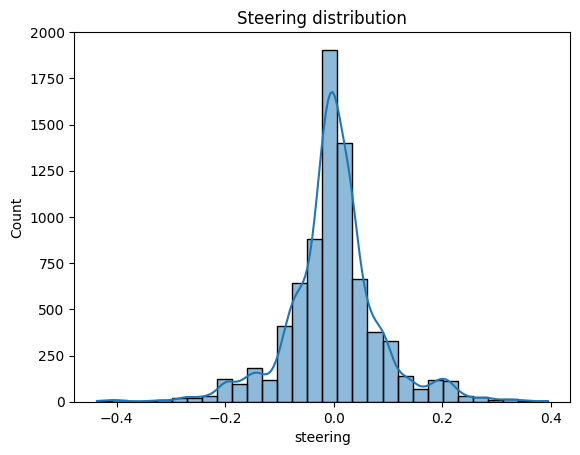

In [2]:
# steering only
sns.histplot(raw_df["steering"], bins=30, kde=True)
plt.xlabel('steering')
plt.title('Steering distribution')
plt.show()

In [5]:
speed_max = raw_df["speed"].max()
speed_max

np.float64(30.6333)

In [6]:
speed_min = raw_df["speed"][df["speed"] > 4].min()
speed_min

np.float64(4.089522)

In [ ]:
# Builds the bin edges from 0 up to just past max speed.
bins = range(0, int(raw_df["speed"].max()) + 2)
counts = pd.cut(raw_df["speed"], bins=bins, right=False).value_counts().sort_index()
counts

speed
[0, 1)        57
[1, 2)         5
[2, 3)         3
[3, 4)         4
[4, 5)         3
[5, 6)         5
[6, 7)         3
[7, 8)         3
[8, 9)         5
[9, 10)        4
[10, 11)       3
[11, 12)       6
[12, 13)       4
[13, 14)       4
[14, 15)       7
[15, 16)       4
[16, 17)       4
[17, 18)       4
[18, 19)       5
[19, 20)       3
[20, 21)       5
[21, 22)       4
[22, 23)       6
[23, 24)       4
[24, 25)       4
[25, 26)       2
[26, 27)       5
[27, 28)       4
[28, 29)       5
[29, 30)       8
[30, 31)    7572
Name: count, dtype: int64

In [4]:
# Builds the bin edges from 0 up to just past max speed.
steer_counts = (
    pd.cut(raw_df["steering"], bins=20)
      .value_counts()
      .sort_index()
)
steer_counts

steering
(-0.437, -0.395]        15
(-0.395, -0.353]         3
(-0.353, -0.311]         9
(-0.311, -0.27]         25
(-0.27, -0.228]         40
(-0.228, -0.187]       134
(-0.187, -0.145]       185
(-0.145, -0.104]       209
(-0.104, -0.0622]      740
(-0.0622, -0.0207]    1194
(-0.0207, 0.0209]     2452
(0.0209, 0.0624]      1516
(0.0624, 0.104]        625
(0.104, 0.145]         220
(0.145, 0.187]         111
(0.187, 0.229]         186
(0.229, 0.27]           37
(0.27, 0.312]           29
(0.312, 0.353]          17
(0.353, 0.395]           8
Name: count, dtype: int64

In [2]:
s = raw_df["steering"]

left  = s[s < 0]
right = s[s > 0]
straight = s[s == 0]  # or abs(s) < 0.05 if you want a deadzone

print("counts")
print("left:", len(left), f"({100*len(left)/len(s):.1f}%)")
print("right:", len(right), f"({100*len(right)/len(s):.1f}%)")
print("straight:", len(straight), f"({100*len(straight)/len(s):.1f}%)")

print("\nmagnitude (sum of |steering|)")
print("left effort:", left.abs().sum())
print("right effort:", right.abs().sum())

print("\naverage |steering| when turning")
print("left mean |steer|:", left.abs().mean())
print("right mean |steer|:", right.abs().mean())

counts
left: 3563 (45.9%)
right: 3435 (44.3%)
straight: 757 (9.8%)

magnitude (sum of |steering|)
left effort: 225.46240508899996
right effort: 224.75075251099997

average |steering| when turning
left mean |steer|: 0.06327881141987088
right mean |steer|: 0.06542962227394468


In [6]:
raw_df.describe()

,steering,throttle,brake,speed
count,7755.000000,7755.000000,7755.000000,7.755000e+03
mean,-0.000092,0.990876,0.000373,2.974083e+01
std,0.085817,0.091426,0.014504,3.291753e+00
min,-0.436090,0.000000,0.000000,8.968499e-08
25%,-0.033835,1.000000,0.000000,3.019002e+01
50%,0.000000,1.000000,0.000000,3.019025e+01
75%,0.033835,1.000000,0.000000,3.019031e+01
max,0.394737,1.000000,0.789407,3.063330e+01


### Histogram Binning Old

near-straight kept: 1290 / 2867
turns: 4822 total: 6112


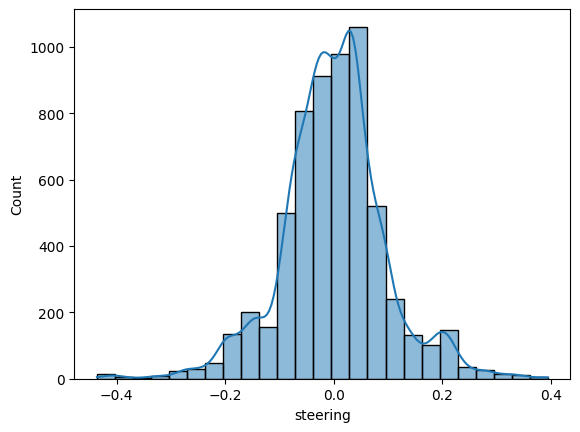

In [ ]:
DEADZONE = 0.025

# if abs. steering is less than deadzone then put into near_straight bins
near_straight = raw_df[
    (raw_df["steering"].abs() < DEADZONE) & (raw_df["throttle"] == 1)
]
# if abs. steering is more than deadzone then put into turn bins
turns = raw_df[raw_df["steering"].abs() >= DEADZONE]

# keep a fraction of near_straight (not all, or the model overfits to 0 steering)
straight = near_straight.sample(frac=0.45, random_state=42)

balanced = pd.concat([straight, turns]).sample(frac=1, random_state=42)
sns.histplot(balanced["steering"], bins=25, kde=True)
print("near-straight kept:", len(straight), "/", len(near_straight))
print("turns:", len(turns), "total:", len(balanced))

### Dynamic Binning New

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# select only those where the throttle is fully pressed
df = raw_df[raw_df["throttle"] == 1].copy()

s = df["steering"].astype(float)
# q25: value at the 25% mark
# q75: value at the 75% mark
q25, q75 = np.percentile(s, [25, 75])
# IQR = q75 - q25: width of the middle 50%
iqr = q75 - q25
# count of all steering values
n = len(s)

# Freedman–Diaconis rule
# allows us to determine bin width
# https://en.wikipedia.org/wiki/Histogram#Number_of_bins_and_width
# https://en.wikipedia.org/wiki/Freedman%E2%80%93Diaconis_rule
# the Freedman–Diaconis rule is designed to approximately minimize the integral of the squared difference
# meaning it will reduce the error between the smooth f(x) curve of the steering values,
# and the current histogram approximation H(x)
# it chooses the correct bin width to reach the smooth continuous curve modeled by f(x)
# f(x) is similar to the kde used in seaborn
# minimizing dx (AKA width of rectangle OR width of histogram bar) can result in more accurate thing
bin_width = 2 * iqr / (n ** (1 / 3)) if iqr > 0 else (s.max() - s.min()) / 20
n_bins = max(int(np.ceil((s.max() - s.min()) / bin_width)), 10)

df["steer_bin"] = pd.cut(df["steering"], bins=n_bins)
df

,center,left,right,steering,throttle,brake,speed,steer_bin
15,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.082707,1.0,0.0,2.840196,"(-0.0888, -0.082]"
16,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.090226,1.0,0.0,3.547080,"(-0.0956, -0.0888]"
17,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.116541,1.0,0.0,4.252328,"(-0.123, -0.116]"
18,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.127820,1.0,0.0,5.182895,"(-0.13, -0.123]"
19,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.131579,1.0,0.0,5.876385,"(-0.136, -0.13]"
...,...,...,...,...,...,...,...,...
7750,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.000000,1.0,0.0,30.190610,"(-0.000246, 0.00656]"
7751,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.000000,1.0,0.0,30.190620,"(-0.000246, 0.00656]"
7752,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.000000,1.0,0.0,30.190620,"(-0.000246, 0.00656]"
7753,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.000000,1.0,0.0,30.190610,"(-0.000246, 0.00656]"


n_bins: 122 max_per_bin: 62
before: 7667
after: 3039


C:\Users\Fawad Arshad\AppData\Local\Temp\ipykernel_428\739736009.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(len(g), max_per_bin), random_state=42))


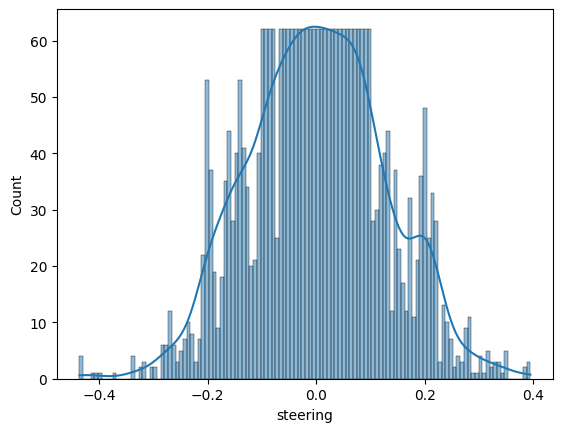

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# select only those where the throttle is fully pressed
df = raw_df[raw_df["throttle"] == 1].copy()

s = df["steering"].astype(float)
# q25: value at the 25% mark
# q75: value at the 75% mark
q25, q75 = np.percentile(s, [25, 75])
# IQR = q75 - q25: width of the middle 50%
iqr = q75 - q25
# count of all steering values
n = len(s)

# Freedman–Diaconis rule
# allows us to determine bin width
# https://en.wikipedia.org/wiki/Histogram#Number_of_bins_and_width
# https://en.wikipedia.org/wiki/Freedman%E2%80%93Diaconis_rule
# the Freedman–Diaconis rule is designed to approximately minimize the integral of the squared difference
# meaning it will reduce the error between the smooth f(x) curve of the steering values,
# and the current histogram approximation H(x)
# it chooses the correct bin width to reach the smooth continuous curve modeled by f(x)
# f(x) is similar to the kde used in seaborn
# minimizing dx (width of rectangle/width of histogram bar) can result in more accurate 
bin_width = 2 * iqr / (n ** (1 / 3)) if iqr > 0 else (s.max() - s.min()) / 20
n_bins = max(int(np.ceil((s.max() - s.min()) / bin_width)), 10)

df["steer_bin"] = pd.cut(df["steering"], bins=n_bins)

counts = df["steer_bin"].value_counts()
#  arbitrarily chosen; it just seemed intuitive.
max_per_bin = int(counts.mean())
print("n_bins:", n_bins, "max_per_bin:", max_per_bin)
print("before:", len(df))

balanced = (
  # observed=True: only include intervals with data; no intervals w/o any rows 
  # group_keys=False: dont add bin label as a new index
  # group by steer_bin because it gives us the intervals
    df.groupby("steer_bin", observed=True, group_keys=False)
    # take random sample from that interval
      .apply(lambda g: g.sample(n=min(len(g), max_per_bin), random_state=42))
      # shuffle
      .sample(frac=1, random_state=42)
      # drop index column
      .reset_index(drop=True)
)
balanced = balanced.drop(columns=["steer_bin"])

print("after:", len(balanced))
sns.histplot(balanced["steering"], bins=n_bins, kde=True)
plt.xlabel("steering")
plt.show()

In [4]:
df.describe()

,steering,throttle,brake,speed
count,7667.000000,7667.0,7667.0,7667.000000
mean,0.000592,1.0,0.0,30.009751
std,0.084940,0.0,0.0,1.827671
min,-0.436090,1.0,0.0,2.433082
25%,-0.033835,1.0,0.0,30.190030
50%,0.000000,1.0,0.0,30.190260
75%,0.033835,1.0,0.0,30.190310
max,0.394737,1.0,0.0,30.633300


In [5]:
balanced.describe()

,steering,throttle,brake,speed
count,3039.000000,3039.0,3039.0,3039.000000
mean,0.002022,1.0,0.0,29.943453
std,0.126032,0.0,0.0,2.033214
min,-0.436090,1.0,0.0,2.840196
25%,-0.086466,1.0,0.0,30.189610
50%,0.000000,1.0,0.0,30.190130
75%,0.086466,1.0,0.0,30.190290
max,0.394737,1.0,0.0,30.492730


In [6]:
balanced.to_csv("balanced_log.csv", index=False)